# 01 — Exploratory Data Analysis: Miracle Sheets

**Project:** RetentionIQ — Predictive Customer Intelligence for Shopify Brands  
**Data Source:** Local CSV exports (`data/raw/orders_raw.csv`, `data/features/customer_features.csv`)  
**Author:** [Your Name]  
**Date:** March 2026  

---

## Purpose

This notebook explores the Miracle Sheets dataset.  
We answer three foundational questions before any modeling:

1. **What does the data look like?** — Volume, shape, completeness, and quality of orders and customers.
2. **How do customers behave?** — Purchase frequency, inter-purchase timing, revenue distribution, refund patterns.
3. **What is the right churn definition?** — Empirical analysis of repurchase cycles to define our churn window.

---

## Table of Contents

1. [Setup & Data Loading](#1-setup)
2. [Schema Exploration](#2-schema)
3. [Orders Overview](#3-orders)
4. [Customer Overview](#4-customers)
5. [Purchase Frequency & Timing](#5-frequency)
6. [Revenue Distribution](#6-revenue)
7. [Refund Patterns](#7-refunds)
8. [Churn Window Analysis](#8-churn-window)
9. [Key Findings & Next Steps](#9-findings)

---
## 1. Setup & Data Loading <a id='1-setup'></a>

We load two local CSV files produced from the Shopify / Daasity export:
- `data/raw/orders_raw.csv` — one row per order
- `data/features/customer_features.csv` — one row per customer (pre-aggregated RFM features)

**Prerequisites:** `pip install -r requirements.txt`

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import os
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(f"Notebook run: {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Notebook run: 2026-03-15 20:00


In [2]:
# ============================================================
# LOAD CSV DATA
# ============================================================
REPO_ROOT   = os.path.dirname(os.path.abspath(''))  # adjust if needed
ORDERS_PATH = os.path.join('..', 'data', 'raw', 'orders_raw.csv')
CUST_PATH   = os.path.join('..', 'data', 'features', 'customer_features.csv')

print('Loading orders_raw.csv …')
orders = pd.read_csv(ORDERS_PATH, parse_dates=['ORDER_DATE'])
orders.columns = orders.columns.str.lower()

print('Loading customer_features.csv …')
cust = pd.read_csv(CUST_PATH, parse_dates=['FIRST_ORDER_DATE', 'LAST_ORDER_DATE'])
cust.columns = cust.columns.str.lower()

# Orders excluding fully voided/refunded records (used for most analyses)
valid_orders = orders[~orders['financial_status'].isin(['refunded', 'voided'])].copy()

print(f'\norders shape       : {orders.shape}')
print(f'cust   shape       : {cust.shape}')
print(f'valid_orders shape : {valid_orders.shape}')

Loading orders_raw.csv …


Loading customer_features.csv …



orders shape       : (976659, 7)
cust   shape       : (751956, 16)
valid_orders shape : (913924, 7)


---
## 2. Schema Exploration <a id='2-schema'></a>

Inspect column names, data types, and a sample of rows from each file.

In [3]:
# ============================================================
# ORDERS SCHEMA
# ============================================================
print('=== orders_raw.csv ===')
print(orders.dtypes)
print(f'\nNull counts:')
print(orders.isnull().sum())
print(f'\nSample rows:')
display(orders.head(3))

=== orders_raw.csv ===
customer_id                 object
order_id                    object
order_tags                  object
order_date          datetime64[ns]
amount_charged             float64
product_amount             float64
financial_status            object
dtype: object

Null counts:
customer_id            829
order_id                 0
order_tags          109395
order_date               0
amount_charged           0
product_amount           0
financial_status         3
dtype: int64

Sample rows:


,customer_id,order_id,order_tags,order_date,amount_charged,product_amount,financial_status
0,000002094a200abd84e6cd40a850edd5,7c6d49d239cd017e22f6df320310f646,"mb-sheets-lp-ksp-v45-out, OFG:Routing rules ma...",2024-06-27 11:01:09,121.48,139.00,paid
1,00000231db4a1580df8e71ad874b23a2,446673c51106f28a573e64794e93da1a,"mb-sheets-ksp-nvs, OFG:Routing rules match, Or...",2025-07-20 10:55:00,128.10,148.99,paid
2,00000de079cccf005064ffd1f4f99836,d06c500b3f9e844e06a6f9e4933c03a8,"mb-sheets-lp-ksp-v45-out, OFG:Routing rules ma...",2024-12-04 17:47:38,119.48,148.99,paid


In [4]:
# ============================================================
# CUSTOMER FEATURES SCHEMA
# ============================================================
print('=== customer_features.csv ===')
print(cust.dtypes)
print(f'\nNull counts:')
print(cust.isnull().sum())
print(f'\nSample rows:')
display(cust.head(3))

=== customer_features.csv ===
customer_id                        object
total_orders                        int64
total_revenue                     float64
avg_order_value                   float64
first_order_date           datetime64[ns]
last_order_date            datetime64[ns]
t                                   int64
recency                             int64
days_since_last_order               int64
frequency                           int64
monetary_value                    float64
avg_days_between_orders           float64
std_days_between_orders           float64
refund_count                        int64
total_refund_amount               float64
refund_rate                       float64
dtype: object

Null counts:
customer_id                0
total_orders               0
total_revenue              0
avg_order_value            0
first_order_date           0
last_order_date            0
t                          0
recency                    0
days_since_last_order      0
frequency

,customer_id,total_orders,total_revenue,avg_order_value,first_order_date,last_order_date,t,recency,days_since_last_order,frequency,monetary_value,avg_days_between_orders,std_days_between_orders,refund_count,total_refund_amount,refund_rate
0,43d49e501840d6909e34db122d651acb,421,49181.28,116.82,2024-01-01 17:01:23,2026-03-15 01:17:31,804,804,0,420,116.82,1.00,0.10,0,0.00,0.00
1,d29cb3376e670e5201dbb7a17f1073cd,81,21915.43,270.56,2024-01-02 22:27:01,2026-02-02 11:19:46,803,762,41,80,270.56,19.50,28.10,0,0.00,0.00
2,612feec0473dcb46b40e499d63f31584,188,16595.83,88.28,2024-01-02 18:30:00,2026-01-20 09:11:46,803,749,54,187,88.28,5.30,5.20,0,0.00,0.00


---
## 3. Orders Overview <a id='3-orders'></a>

High-level stats on the order table: total volume, date range, financial status breakdown.

In [5]:
# ============================================================
# ORDERS: HIGH-LEVEL SUMMARY
# ============================================================
print('ORDERS — HIGH-LEVEL SUMMARY')
print('=' * 50)
print(f"  total_orders       : {len(orders):,}")
print(f"  unique_customers   : {orders['customer_id'].nunique():,}")
print(f"  earliest_order     : {orders['order_date'].min().date()}")
print(f"  latest_order       : {orders['order_date'].max().date()}")
print(f"  total_revenue      : ${valid_orders['amount_charged'].sum():,.2f}")
print(f"  avg_order_value    : ${valid_orders['amount_charged'].mean():.2f}")
print(f"  median_order_value : ${valid_orders['amount_charged'].median():.2f}")

ORDERS — HIGH-LEVEL SUMMARY
  total_orders       : 976,659


  unique_customers   : 801,039
  earliest_order     : 2024-01-01
  latest_order       : 2026-03-14
  total_revenue      : $155,911,857.82
  avg_order_value    : $170.60
  median_order_value : $151.11


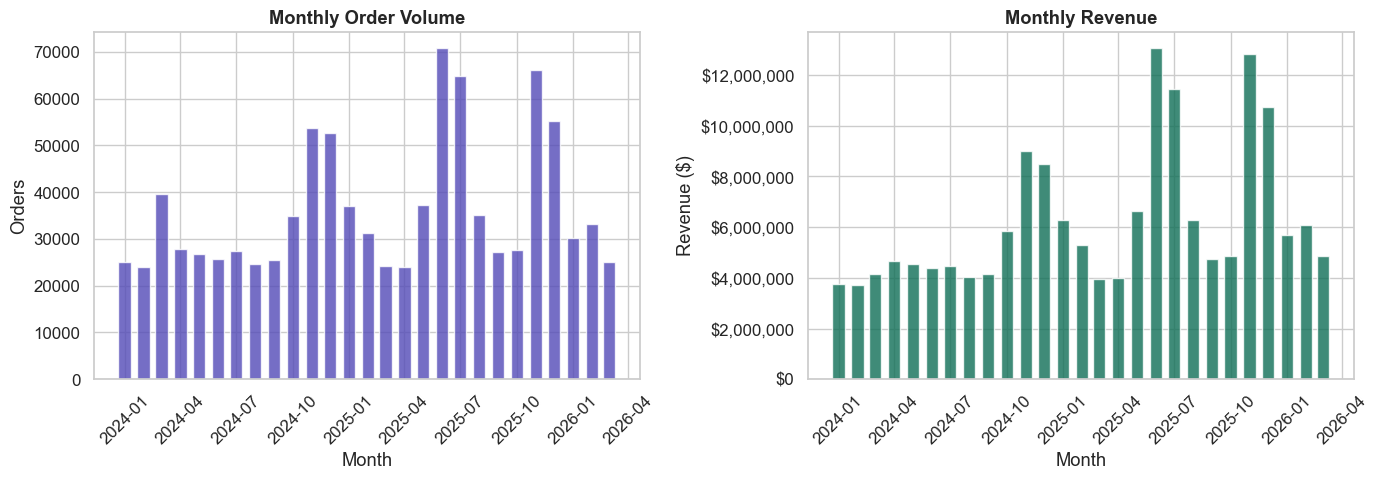

In [6]:
# ============================================================
# ORDERS OVER TIME — Monthly trend
# ============================================================
orders['month'] = orders['order_date'].dt.to_period('M').dt.to_timestamp()
orders_monthly = orders.groupby('month').agg(
    order_count=('order_id', 'count'),
    unique_customers=('customer_id', 'nunique'),
    revenue=('amount_charged', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(orders_monthly['month'], orders_monthly['order_count'],
            color='#534AB7', alpha=0.8, width=20)
axes[0].set_title('Monthly Order Volume', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Orders')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(orders_monthly['month'], orders_monthly['revenue'],
            color='#0F6E56', alpha=0.8, width=20)
axes[1].set_title('Monthly Revenue', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# FINANCIAL STATUS BREAKDOWN
# ============================================================
fin_status = orders.groupby('financial_status').agg(
    order_count=('order_id', 'count'),
    total_revenue=('amount_charged', 'sum')
).sort_values('order_count', ascending=False)
fin_status['pct'] = (fin_status['order_count'] / len(orders) * 100).round(1)

print('FINANCIAL STATUS BREAKDOWN')
display(fin_status)

FINANCIAL STATUS BREAKDOWN


,order_count,total_revenue,pct
financial_status,,,
paid,872300,145840267.97,89.30
refunded,62722,11987982.20,6.40
partially_refunded,41385,10034373.98,4.20
pending,235,37153.79,0.00
voided,13,5340.71,0.00
authorized,1,62.08,0.00


---
## 4. Customer Overview <a id='4-customers'></a>

How many customers are repeat vs. one-time buyers?

In [8]:
# ============================================================
# ORDERS PER CUSTOMER
# Using customer_features.csv which is pre-aggregated.
# ============================================================
total_customers = len(cust)
one_time = (cust['total_orders'] == 1).sum()
repeat   = total_customers - one_time

print(f"Total customers  : {total_customers:,}")
print(f"One-time buyers  : {one_time:,} ({one_time/total_customers*100:.1f}%)")
print(f"Repeat buyers    : {repeat:,} ({repeat/total_customers*100:.1f}%)")
print(f"\nOrders per customer — descriptive stats:")
print(cust['total_orders'].describe(percentiles=[.5, .75, .9, .95, .99]).to_string())

Total customers  : 751,956
One-time buyers  : 659,934 (87.8%)
Repeat buyers    : 92,022 (12.2%)

Orders per customer — descriptive stats:
count   751956.00
mean         1.18
std          0.85
min          1.00
50%          1.00
75%          1.00
90%          2.00
95%          2.00
99%          4.00
max        421.00


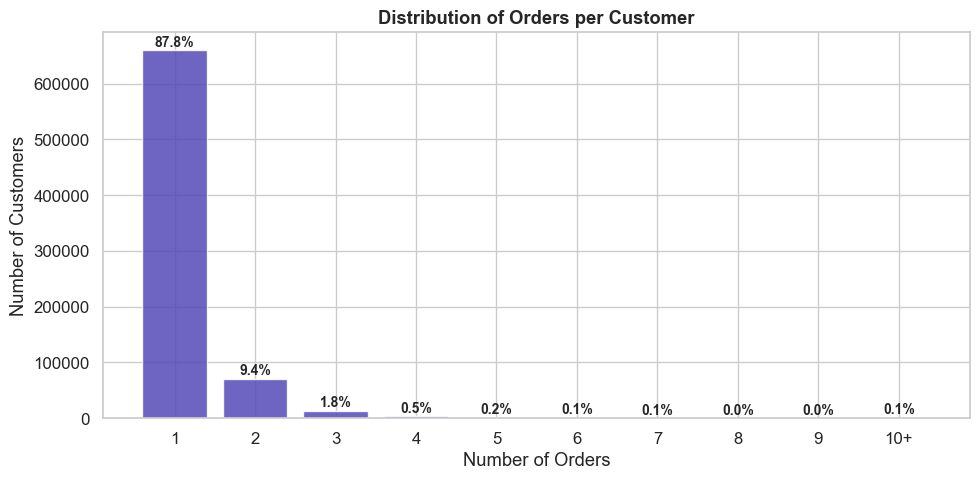


→ 88% of customers buy only once. Converting even 10% to repeat buyers could significantly impact revenue.


In [9]:
# ============================================================
# ORDER COUNT DISTRIBUTION — Histogram
# ============================================================
order_counts = cust['total_orders'].clip(upper=10)

fig, ax = plt.subplots(figsize=(10, 5))
counts = order_counts.value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color='#534AB7', alpha=0.85, edgecolor='white')

for bar, val in zip(bars, counts.values):
    pct = val / total_customers * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + total_customers*0.002,
            f'{pct:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
ax.set_title('Distribution of Orders per Customer', fontweight='bold')
ax.set_xticks(range(1, 11))
ax.set_xticklabels([str(i) if i < 10 else '10+' for i in range(1, 11)])
plt.tight_layout()
plt.show()

print(f"\n→ {one_time/total_customers*100:.0f}% of customers buy only once. "
      f"Converting even 10% to repeat buyers could significantly impact revenue.")

---
## 5. Purchase Frequency & Timing <a id='5-frequency'></a>

The inter-purchase time distribution defines our churn window (Section 8)  
and is the empirical basis for the BG/NBD model.  
We analyse only customers with 2+ orders (repeat buyers).

In [10]:
# ============================================================
# INTER-PURCHASE TIME — Days between consecutive orders
# ============================================================
print('Computing inter-purchase intervals (may take ~30s for ~1M rows) …')
s = valid_orders.sort_values(['customer_id', 'order_date'])
s['prev_order_date'] = s.groupby('customer_id')['order_date'].shift(1)
s['days_between'] = (s['order_date'] - s['prev_order_date']).dt.days

inter_purchase = s.dropna(subset=['prev_order_date'])
inter_purchase = inter_purchase[inter_purchase['days_between'] > 0]
days = inter_purchase['days_between']

print(f"Total inter-purchase intervals: {len(days):,}")
print(f"\nDays between orders — Summary Statistics:")
print(days.describe(percentiles=[.25, .5, .75, .9, .95]).to_string())

Computing inter-purchase intervals (may take ~30s for ~1M rows) …


Total inter-purchase intervals: 118,006

Days between orders — Summary Statistics:
count   118006.00
mean       115.05
std        134.91
min          1.00
25%         22.00
50%         59.00
75%        167.00
90%        318.00
95%        404.00
max        799.00


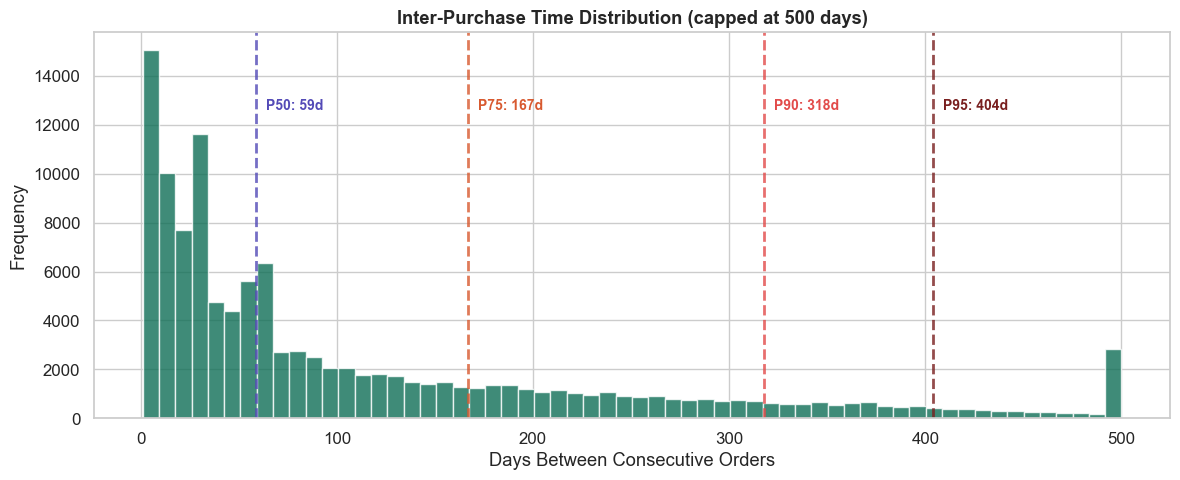


→ Median repurchase time : 59 days
  P90 repurchase time    : 318 days — recommended churn window
  P95 repurchase time    : 404 days — conservative churn window


In [11]:
# ============================================================
# INTER-PURCHASE TIME DISTRIBUTION — Histogram + Key Percentiles
# ============================================================
p50 = days.quantile(0.50)
p75 = days.quantile(0.75)
p90 = days.quantile(0.90)
p95 = days.quantile(0.95)

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(days.clip(upper=500), bins=60, color='#0F6E56', alpha=0.8, edgecolor='white')

for pval, plabel, color in [(p50, 'P50', '#534AB7'), (p75, 'P75', '#D85A30'),
                             (p90, 'P90', '#E24B4A'), (p95, 'P95', '#791F1F')]:
    ax.axvline(pval, color=color, linestyle='--', linewidth=2, alpha=0.8)
    ax.text(pval + 5, ax.get_ylim()[1] * 0.8, f'{plabel}: {pval:.0f}d',
            color=color, fontweight='bold', fontsize=10)

ax.set_xlabel('Days Between Consecutive Orders')
ax.set_ylabel('Frequency')
ax.set_title('Inter-Purchase Time Distribution (capped at 500 days)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n→ Median repurchase time : {p50:.0f} days")
print(f"  P90 repurchase time    : {p90:.0f} days — recommended churn window")
print(f"  P95 repurchase time    : {p95:.0f} days — conservative churn window")

---
## 6. Revenue Distribution <a id='6-revenue'></a>

How is revenue distributed across customers? DTC brands typically follow a Pareto pattern.

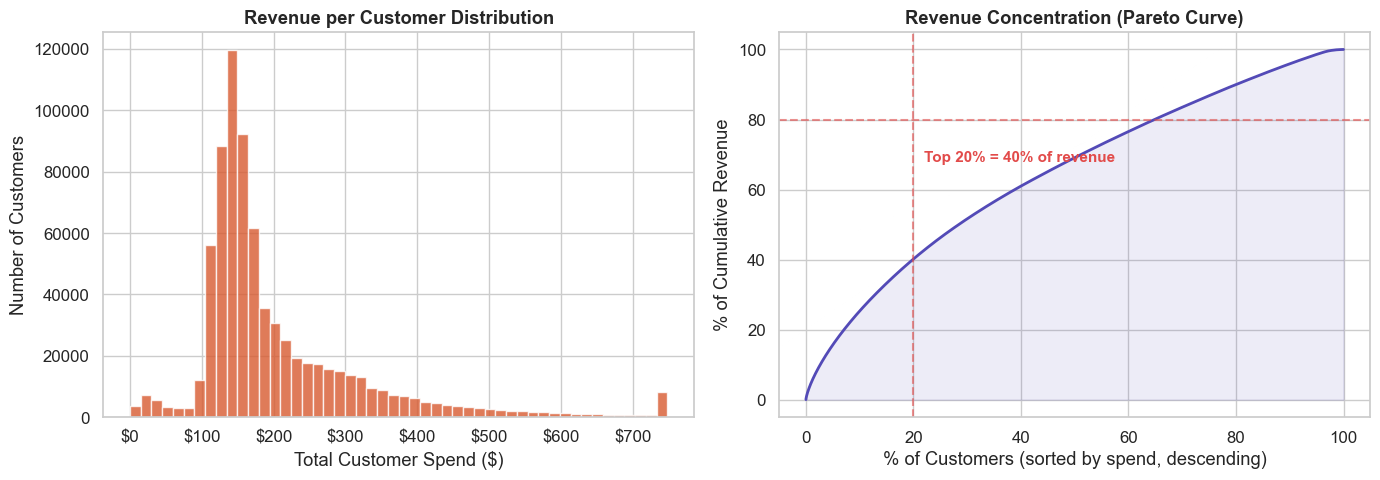

→ Top 20% of customers generate 40% of total revenue (Pareto ratio)


In [12]:
# ============================================================
# REVENUE PER CUSTOMER — Pareto Curve
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

spend = cust['total_revenue']
cap   = spend.quantile(0.99)
axes[0].hist(spend.clip(upper=cap), bins=50, color='#D85A30', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Total Customer Spend ($)')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Revenue per Customer Distribution', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sorted_spend = spend.sort_values(ascending=False).reset_index(drop=True)
cum_pct  = sorted_spend.cumsum() / sorted_spend.sum() * 100
cust_pct = np.arange(1, len(cum_pct) + 1) / len(cum_pct) * 100

axes[1].plot(cust_pct, cum_pct.values, color='#534AB7', linewidth=2)
axes[1].axhline(80, color='#E24B4A', linestyle='--', alpha=0.6)
axes[1].axvline(20, color='#E24B4A', linestyle='--', alpha=0.6)
axes[1].fill_between(cust_pct, cum_pct.values, alpha=0.1, color='#534AB7')

top20_rev = sorted_spend.iloc[:int(len(sorted_spend) * 0.20)].sum()
pareto_pct = top20_rev / sorted_spend.sum() * 100
axes[1].text(22, 68, f'Top 20% = {pareto_pct:.0f}% of revenue',
             fontsize=11, fontweight='bold', color='#E24B4A')
axes[1].set_xlabel('% of Customers (sorted by spend, descending)')
axes[1].set_ylabel('% of Cumulative Revenue')
axes[1].set_title('Revenue Concentration (Pareto Curve)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"→ Top 20% of customers generate {pareto_pct:.0f}% of total revenue (Pareto ratio)")

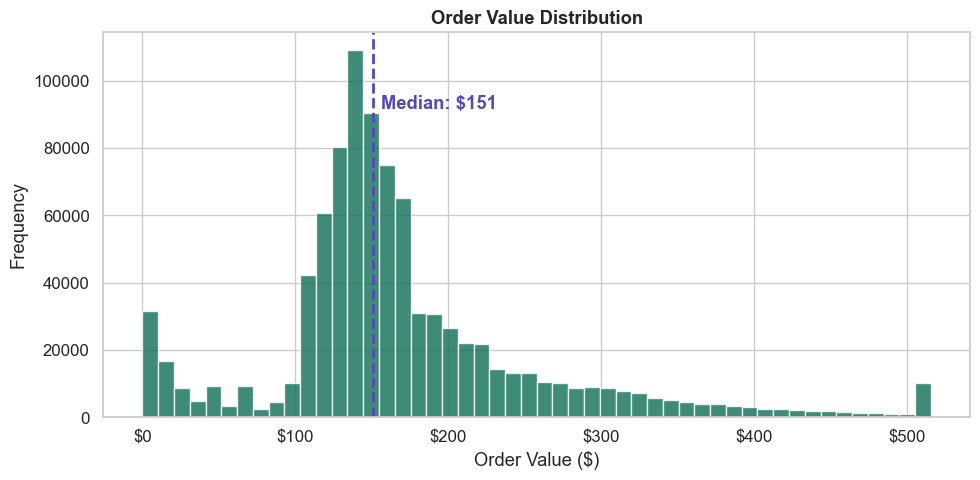

In [13]:
# ============================================================
# AOV DISTRIBUTION
# ============================================================
aov = valid_orders['amount_charged']
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(aov.clip(upper=aov.quantile(0.99)), bins=50, color='#0F6E56', alpha=0.8, edgecolor='white')
ax.axvline(aov.median(), color='#534AB7', linestyle='--', linewidth=2)
ax.text(aov.median() + 5, ax.get_ylim()[1]*0.8,
        f'Median: ${aov.median():.0f}', color='#534AB7', fontweight='bold')
ax.set_xlabel('Order Value ($)')
ax.set_ylabel('Frequency')
ax.set_title('Order Value Distribution', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

---
## 7. Refund Patterns <a id='7-refunds'></a>

Refund behavior is a strong churn predictor. Discount analysis requires a richer data pull
(discount codes are not present in `orders_raw.csv` — add to Shopify extraction in `src/ingestion/`).

In [14]:
# ============================================================
# REFUND ANALYSIS — from customer_features
# ============================================================
cust_with_refund = (cust['refund_count'] > 0).sum()
print('REFUND SUMMARY')
print(f"  Customers with ≥1 refund : {cust_with_refund:,}  "
      f"({cust_with_refund/len(cust)*100:.1f}% of all customers)")
print(f"  Total refund amount      : ${cust['total_refund_amount'].sum():,.2f}")
print(f"  Avg refund rate per cust : {cust['refund_rate'].mean()*100:.2f}%")

# Refund orders from order table
refund_orders = orders[orders['financial_status'].isin(['refunded', 'partially_refunded'])]
print(f"\n  Refund/partial-refund orders : {len(refund_orders):,}  "
      f"({len(refund_orders)/len(orders)*100:.1f}% of all orders)")
print(f"  Value of those orders        : ${refund_orders['amount_charged'].sum():,.2f}")

print("""
⚠️  Discount Analysis
  orders_raw.csv has no discount_code column.
  ORDER_TAGS contains routing/fulfillment tags, not discount codes.
  → Add discount_codes field to src/ingestion/extract_orders.py.
""")

REFUND SUMMARY
  Customers with ≥1 refund : 53,161  (7.1% of all customers)
  Total refund amount      : $235,671.33
  Avg refund rate per cust : 7.10%

  Refund/partial-refund orders : 104,107  (10.7% of all orders)
  Value of those orders        : $22,022,356.18

⚠️  Discount Analysis
  orders_raw.csv has no discount_code column.
  ORDER_TAGS contains routing/fulfillment tags, not discount codes.
  → Add discount_codes field to src/ingestion/extract_orders.py.



---
## 8. Churn Window Analysis <a id='8-churn-window'></a>

**This is the single most important analysis in the notebook.**

We use the empirical inter-purchase time distribution to choose the churn window —
the number of days of silence after which a customer is considered churned.

In [15]:
# ============================================================
# CHURN WINDOW SENSITIVITY ANALYSIS
# ============================================================
windows = [60, 90, 120, 150, 180, 240, 318, 365]

print('CHURN WINDOW SENSITIVITY ANALYSIS')
print('=' * 65)
print(f"{'Window (days)':<18} {'% intervals within':<22} Note")
print('-' * 65)
for w in windows:
    pct = (days <= w).mean() * 100
    note = '← P90 (recommended)' if w == 318 else ''
    print(f"  {w:<16} {pct:>6.1f}%               {note}")

print(f"\n→ P90 of inter-purchase intervals = {p90:.0f} days.")
print(f"  Use {p90:.0f} days as the churn window — it captures 90% of real repurchases")
print(f"  without falsely labelling slow-but-active customers as churned.")

CHURN WINDOW SENSITIVITY ANALYSIS
Window (days)      % intervals within     Note
-----------------------------------------------------------------
  60                 52.9%               
  90                 61.8%               
  120                67.9%               
  150                72.8%               
  180                76.9%               
  240                83.7%               
  318                90.1%               ← P90 (recommended)
  365                93.0%               

→ P90 of inter-purchase intervals = 318 days.
  Use 318 days as the churn window — it captures 90% of real repurchases
  without falsely labelling slow-but-active customers as churned.


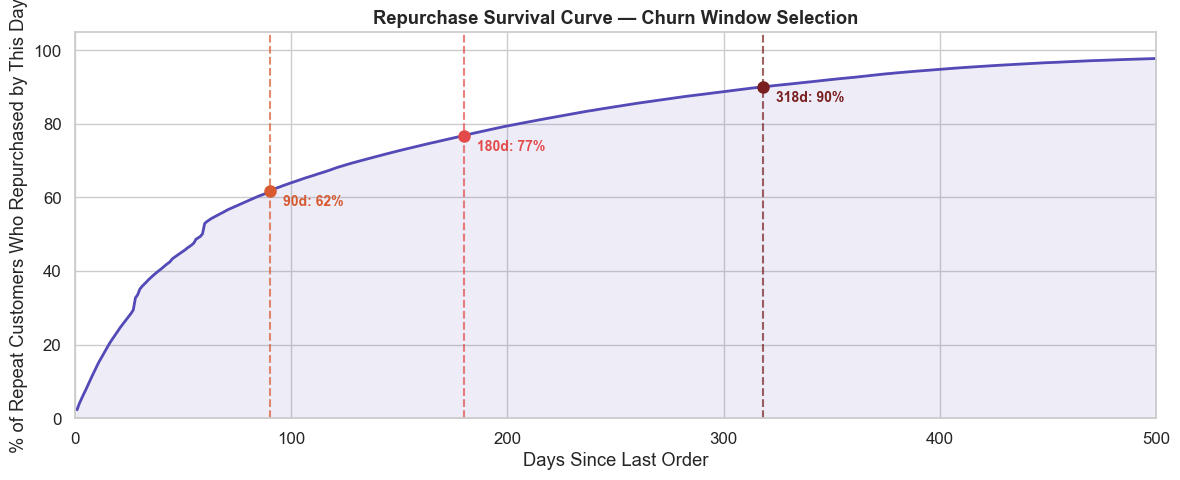

In [16]:
# ============================================================
# SURVIVAL CURVE
# ============================================================
max_days = 500
day_range = range(1, max_days + 1)
pcts = [(days <= d).mean() * 100 for d in day_range]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(list(day_range), pcts, color='#534AB7', linewidth=2)
ax.fill_between(list(day_range), pcts, alpha=0.1, color='#534AB7')

for w, color in [(90, '#D85A30'), (180, '#E24B4A'), (int(p90), '#791F1F')]:
    pct_w = (days <= w).mean() * 100
    ax.axvline(w, color=color, linestyle='--', alpha=0.7)
    ax.plot(w, pct_w, 'o', color=color, markersize=8)
    ax.text(w + 6, pct_w - 4, f'{w}d: {pct_w:.0f}%', color=color, fontweight='bold', fontsize=10)

ax.set_xlabel('Days Since Last Order')
ax.set_ylabel('% of Repeat Customers Who Repurchased by This Day')
ax.set_title('Repurchase Survival Curve — Churn Window Selection', fontweight='bold')
ax.set_xlim(0, max_days)
ax.set_ylim(0, 105)
plt.tight_layout()
plt.show()

---
## 9. Key Findings & Next Steps <a id='9-findings'></a>

In [17]:
# ============================================================
# PRINT SUMMARY TABLE
# ============================================================
pareto_pct_val = sorted_spend.iloc[:int(len(sorted_spend)*0.20)].sum() / sorted_spend.sum() * 100

print('=' * 60)
print('  KEY FINDINGS — MIRACLE SHEETS EDA')
print('=' * 60)
print(f"  Total customers          : {len(cust):,}")
print(f"  One-time buyer rate      : {one_time/total_customers*100:.1f}%")
print(f"  Median inter-purchase    : {p50:.0f} days")
print(f"  P90 inter-purchase (→ churn window) : {p90:.0f} days")
print(f"  Pareto ratio (top 20%)   : {pareto_pct_val:.0f}% of revenue")
print(f"  Refund rate              : {cust_with_refund/len(cust)*100:.1f}% of customers")
print('=' * 60)
print()
print('DECISIONS:')
print(f"  Churn window   → {int(p90)} days")
print(f"  Orders to use  → financial_status IN ('paid','partially_refunded')")
print()
print('NEXT STEPS:')
print('  1. Add discount_codes to ingestion (src/ingestion/extract_orders.py)')
print('  2. Notebook 02 — feature engineering pipeline')
print('  3. Notebook 03 — BG/NBD + Gamma-Gamma CLV model')
print('  4. Notebook 04 — XGBoost churn classifier with', int(p90), 'day window')

  KEY FINDINGS — MIRACLE SHEETS EDA
  Total customers          : 751,956
  One-time buyer rate      : 87.8%
  Median inter-purchase    : 59 days
  P90 inter-purchase (→ churn window) : 318 days
  Pareto ratio (top 20%)   : 40% of revenue
  Refund rate              : 7.1% of customers

DECISIONS:
  Churn window   → 318 days
  Orders to use  → financial_status IN ('paid','partially_refunded')

NEXT STEPS:
  1. Add discount_codes to ingestion (src/ingestion/extract_orders.py)
  2. Notebook 02 — feature engineering pipeline
  3. Notebook 03 — BG/NBD + Gamma-Gamma CLV model
  4. Notebook 04 — XGBoost churn classifier with 318 day window
